## Step 1: Install Dependencies

In [1]:
!pip install -q umap-learn scikit-learn matplotlib seaborn tqdm requests librosa yt-dlp
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
print('All packages installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 45.1 MB/s eta 0:00:00
All packages installed!


## Step 2: Import Libraries

In [2]:
import os, warnings, zipfile, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
import requests
import librosa
import librosa.display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import umap

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Libraries loaded | Device: {DEVICE}')

Libraries loaded | Device: cuda


## Step 3: Download English Songs via yt-dlp

In [3]:
import subprocess, os

ENGLISH_DIR = '/content/english'
os.makedirs(ENGLISH_DIR, exist_ok=True)

ENGLISH_GENRES = {
    'Rock':'ytsearch20:classic rock songs hits 30 seconds',
    'Pop':'ytsearch20:english pop music hits songs',
    'Jazz':'ytsearch20:jazz music instrumental classic',
    'Classical':'ytsearch20:classical music orchestral symphony',
    'HipHop':'ytsearch20:hip hop rap music hits songs',
    'Blues':'ytsearch20:blues guitar music classic songs',
    'Country':'ytsearch20:country music songs classic hits',
}

N_PER_GENRE_EN = 20
CLIP_DURATION = 30


def download_genre_yt(genre_name, search_query, out_dir, n=20):
    genre_dir = f'{out_dir}/{genre_name}'
    os.makedirs(genre_dir, exist_ok=True)

    existing = len([f for f in os.listdir(genre_dir) if f.endswith('.wav')])
    if existing >= n:
        print(f'{genre_name}: {existing} tracks already downloaded, skipping.')
        return

    print(f'Downloading {genre_name} (target {n})...')

    cmd = [
        'yt-dlp',
        '--quiet',
        '--no-warnings',
        '--extract-audio',
        '--audio-format', 'wav',
        '--audio-quality', '0',
        '--postprocessor-args', f'-t {CLIP_DURATION}',
        '--output', f'{genre_dir}/%(title)s.%(ext)s',
        '--playlist-end', str(n),
        '--no-playlist',
        search_query
    ]

    try:
        subprocess.run(cmd, timeout=300)
    except subprocess.TimeoutExpired:
        print(f'{genre_name}: Timeout reached. Using partial downloads')

    # ALWAYS count what we got (even after timeout)
    downloaded = len([f for f in os.listdir(genre_dir) if f.endswith('.wav')])

    if downloaded == 0:
        print(f'{genre_name}: No tracks downloaded')
    else:
        print(f'{genre_name}: {downloaded} tracks available (used for training)')


print('Downloading English songs by genre from YouTube...')
for genre, query in ENGLISH_GENRES.items():
    try:
        download_genre_yt(genre, query, ENGLISH_DIR, n=N_PER_GENRE_EN)
    except Exception as e:
        print(f'Skipping {genre} due to error: {e}')
        continue


print('\nEnglish dataset summary:')
total_english = 0

for genre in ENGLISH_GENRES:
    gdir = f'{ENGLISH_DIR}/{genre}'
    n = len([f for f in os.listdir(gdir) if f.endswith('.wav')]) if os.path.exists(gdir) else 0
    total_english += n
    print(f'{genre:15s}: {n} tracks')

print(f'{total_english} tracks')

Rock: 20 tracks available (used for training)
Pop: Timeout reached. Using partial downloads
Pop: 3 tracks available (used for training)
Jazz: Timeout reached. Using partial downloads
Jazz: 2 tracks available (used for training)
Classical: 20 tracks available (used for training)
HipHop: 19 tracks available (used for training)
Blues: Timeout reached. Using partial downloads
Blues: 11 tracks available (used for training)
Country: 17 tracks available (used for training)

English dataset summary:
Rock           : 20 tracks
Pop            : 3 tracks
Jazz           : 2 tracks
Classical      : 20 tracks
HipHop         : 19 tracks
Blues          : 11 tracks
Country        : 17 tracks
92 tracks


## Step 4: Download Bangla Songs via yt-dlp

In [4]:
import glob
import os
import subprocess

In [5]:
BANGLA_DIR = '/content/bangla'
os.makedirs(BANGLA_DIR, exist_ok=True)

# YouTube search queries per Bangla genre — each will download up to N_PER_GENRE tracks
BANGLA_GENRES = {
    'Baul':'ytsearch20:bangla baul song folk mystic',
    'Folk':'ytsearch20:bangla folk gaan traditional',
    'Rabindra':'ytsearch20:rabindra sangeet tagore bengali song',
    'ModernPop':'ytsearch20:modern bangla pop song hits',
    'Classical':'ytsearch20:bangla classical music ustad',
}

N_PER_GENRE = 20   # up to 20 songs per genre → ~100 Bangla tracks total
CLIP_DURATION = 30 # seconds

def download_bangla_genre(genre_name, search_query, out_dir, n=20):
    genre_dir = f'{out_dir}/{genre_name}'
    os.makedirs(genre_dir, exist_ok=True)

    existing = len([f for f in os.listdir(genre_dir) if f.endswith('.wav')])
    if existing >= n:
        print(f'{genre_name}: {existing} tracks already downloaded, skipping.')
        return

    print(f'Downloading {genre_name} ({n} tracks)...')
    cmd = [
        'yt-dlp',
        '--quiet',
        '--no-warnings',
        '--extract-audio',
        '--audio-format', 'wav',
        '--audio-quality', '0',
        '--postprocessor-args', f'-t {CLIP_DURATION}',  # clip to 30s
        '--output', f'{genre_dir}/%(title)s.%(ext)s',
        '--playlist-end', str(n),
        '--no-playlist',
        search_query
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
    downloaded = len([f for f in os.listdir(genre_dir) if f.endswith('.wav')])
    print(f'{genre_name}: {downloaded} tracks downloaded.')

print('Downloading Bangla songs by genre...')
for genre, query in BANGLA_GENRES.items():
    download_bangla_genre(genre, query, BANGLA_DIR, n=N_PER_GENRE)

print('\nBangla dataset summary:')
total_bangla = 0
for genre in BANGLA_GENRES:
    gdir = f'{BANGLA_DIR}/{genre}'
    n = len([f for f in os.listdir(gdir) if f.endswith('.wav')]) if os.path.exists(gdir) else 0
    total_bangla += n
    print(f'{genre:15s}: {n} tracks')
print(f'{"TOTAL":15s}: {total_bangla} tracks')

Baul: 0 tracks downloaded.
Folk: 0 tracks downloaded.
Rabindra: 1 tracks downloaded.
ModernPop: 0 tracks downloaded.
Classical: 0 tracks downloaded.

Bangla dataset summary:
Baul           : 0 tracks
Folk           : 0 tracks
Rabindra       : 1 tracks
ModernPop      : 0 tracks
Classical      : 0 tracks
TOTAL          : 1 tracks


## Step 5: Feature Extraction with Librosa

In [7]:
import os, re
import numpy as np
import librosa
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD


# Actual dim breakdown: 40+13+12+8+6+9+3+2+9 = 102  (was silently trimmed to 100)
AUDIO_DIM  = 102   # FIXED: matches actual concatenated dims exactly
LYRICS_DIM = 0
TOTAL_DIM  = AUDIO_DIM + LYRICS_DIM  # 122


def extract_audio_features(file_path, sr=22050, duration=30):
    try:
        y, sr = librosa.load(file_path, sr=sr, duration=duration, mono=True)
        if len(y) < sr * 2:
            return None

        # 1. MFCCs — 40 dims
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        mfcc_mean = np.mean(mfcc, axis=1)# (40,)

        # 2. MFCC Deltas — 13 dims
        mfcc_delta = librosa.feature.delta(mfcc[:13])
        mfcc_delta_mean = np.mean(mfcc_delta, axis=1)# (13,)

        # 3. Chroma STFT — 12 dims
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)# (12,)

        # 4. Mel-spectrogram stats — 8 dims (mean+std × 4 bands)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db= librosa.power_to_db(mel_spec, ref=np.max)
        bands= np.array_split(mel_db, 4, axis=0)
        mel_stats = np.array([
            stat for band in bands
            for stat in (np.mean(band), np.std(band))
        ])# (8,)

        # 5. Tonnetz — 6 dims
        tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
        tonnetz_mean = np.mean(tonnetz, axis=1)# (6,)



        # 6. Spectral features — 9 dims (FIXED: pinned output shape)
        spec_centroid  = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))   # 1
        spec_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))  # 1
        spec_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))    # 1

        spec_contrast_raw = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=4)
        spec_contrast = np.mean(spec_contrast_raw, axis=1)[:4]   # force exactly 4 values

        onset_env     = librosa.onset.onset_strength(y=y, sr=sr)
        spec_flux     = np.mean(onset_env)# 1
        spec_flatness = np.mean(librosa.feature.spectral_flatness(y=y))# 1

        spectral_feats = np.array([
            spec_centroid, spec_bandwidth, spec_rolloff,
            *spec_contrast,# exactly 4
            spec_flux, spec_flatness # 2
        ])# total = 9

        # 7. Rhythm — 3 dims
        tempo, beats  = librosa.beat.beat_track(y=y, sr=sr)
        beat_strength = np.mean(onset_env[beats]) if len(beats) > 0 else 0.0
        onset_rate    = len(librosa.onset.onset_detect(y=y, sr=sr)) / (len(y) / sr)
        rhythm_feats  = np.array([float(tempo), beat_strength, onset_rate])  # (3,)

        # 8. ZCR + RMS — 2 dims
        zcr = np.mean(librosa.feature.zero_crossing_rate(y=y))
        rms = np.mean(librosa.feature.rms(y=y))
        energy_feats = np.array([zcr, rms])# (2,)

        # 9. Chroma CQT — 9 dims
        chroma_cqt   = librosa.feature.chroma_cqt(y=y, sr=sr)
        chroma_cqt_m = np.mean(chroma_cqt, axis=1)[:9]# (9,)

        feature_vec = np.concatenate([
            mfcc_mean,# 40
            mfcc_delta_mean,# 13
            chroma_mean,# 12
            mel_stats,#  8
            tonnetz_mean,#  6
            spectral_feats,#  9  (FIXED: no silent trim)
            rhythm_feats,#  3
            energy_feats,#  2
            chroma_cqt_m,#  9
        ])# total = 102 — matches AUDIO_DIM exactly

        # Safety pad/trim (should never trigger now, but kept as guard)
        if len(feature_vec) != AUDIO_DIM:
            print(f'Unexpected dim {len(feature_vec)} for {file_path}, adjusting.')
            if len(feature_vec) > AUDIO_DIM:
                feature_vec = feature_vec[:AUDIO_DIM]
            else:
                feature_vec = np.pad(feature_vec, (0, AUDIO_DIM - len(feature_vec)))

        return feature_vec

    except Exception as e:
        return None


print('Deep audio feature extraction ready.')
print(f'Audio feature vector: {AUDIO_DIM} dims (no silent trimming)')
print('MFCCs×40 | MFCC-Δ×13 | Chroma×12 | Mel-stats×8 |'
      ' Tonnetz×6 | Spectral×9 | Rhythm×3 | ZCR+RMS×2 | ChromaCQT×9')



GENRE_LYRICS_SEEDS = {
    'pop':'love heart dance floor night feel emotions chorus hook beat drop',
    'rock':'rebel fight loud guitar riff freedom raw power scream noise',
    'jazz':'blues swing improvise soul night bar trumpet scat cool groove',
    'classical':'symphony movement allegro sonata orchestral harmony counterpoint theme',
    'hiphop':'flow bars rhyme verse hustle street rap beat producer sample',
    'electronic': 'synth drop bass filter wave pulse rave circuit machine loop',
    'folk':'river mountain story old ballad countryside wooden fiddle simple',
    'rnb':'smooth groove rhythm soulful melody sensual harmony velvet night',
    'baul':'mon akash nodi bhalobasha fakir dotar song soul river mystic',
    'rabindrasangeet': 'prem akash alo ananda brishti shanto hriday kotha gan',
    'nazrul':'bidrohi fire jago shokal shondhya desher gaan patriot rhythm',
    'adhunik':'bhalobasha jibon smriti kotha mon hashi kanna shukh dukho',
    'folk_bangla':'nodir kule gram gaon mati shonar bangla desh maa bhalobasha',
    'film':'nacho gao khushi ananda hero heroine scene song soundtrack',
}

def load_lyrics_for_track(audio_path):
    base= os.path.splitext(audio_path)[0]
    genre_dir = os.path.dirname(audio_path)
    if os.path.exists(base + '.txt'):
        with open(base + '.txt', 'r', encoding='utf-8', errors='ignore') as f:
            return f.read().strip()
    fname_txt= os.path.splitext(os.path.basename(audio_path))[0] + '.txt'
    lyrics_path = os.path.join(genre_dir, 'lyrics', fname_txt)
    if os.path.exists(lyrics_path):
        with open(lyrics_path, 'r', encoding='utf-8', errors='ignore') as f:
            return f.read().strip()
    return None


def build_lyrics_corpus(records):
    corpus, has_real_lyrics = [], []
    for rec in records:
        lyrics = load_lyrics_for_track(rec['file'])
        if lyrics and len(lyrics.strip()) > 10:
            corpus.append(lyrics)
            has_real_lyrics.append(True)
        else:

            corpus.append('music song melody rhythm audio sound')
            has_real_lyrics.append(False)

    n_real = sum(has_real_lyrics)
    print(f'Lyrics coverage: {n_real}/{len(records)} tracks have real lyrics '
          f'({100*n_real/max(len(records),1):.1f}%)')
    if n_real == 0:
        print('No real lyrics found — lyric dims will carry no signal.')
        print('Consider audio-only mode or providing .txt lyric files.')
    return corpus, has_real_lyrics


def fit_lyrics_embedder(corpus, n_components=LYRICS_DIM, max_features=2000):
    vectorizer = TfidfVectorizer(
        max_features=max_features, ngram_range=(1, 2),
        sublinear_tf=True, min_df=1,
        strip_accents='unicode', analyzer='word',
    )
    tfidf_matrix = vectorizer.fit_transform(corpus)
    n_comp = min(n_components, tfidf_matrix.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    lyric_embeddings = svd.fit_transform(tfidf_matrix)
    if lyric_embeddings.shape[1] < n_components:
        pad = np.zeros((lyric_embeddings.shape[0], n_components - lyric_embeddings.shape[1]))
        lyric_embeddings = np.hstack([lyric_embeddings, pad])
    print(f'TF-IDF vocab: {len(vectorizer.vocabulary_)} | '
          f'LSA explained var: {svd.explained_variance_ratio_.sum():.3f}')
    return vectorizer, svd, lyric_embeddings




records = []

print('\nExtracting audio features — English...')
for genre in tqdm(list(ENGLISH_GENRES.keys()), desc='English genres'):
    genre_path = f'{ENGLISH_DIR}/{genre}'
    if not os.path.exists(genre_path):
        continue
    files = [f for f in os.listdir(genre_path)
             if f.endswith('.wav') or f.endswith('.mp3')][:20]
    for fname in files:
        fpath = os.path.join(genre_path, fname)
        feat  = extract_audio_features(fpath)
        if feat is not None:
            records.append({'file': fpath, 'genre': genre,
                            'language': 'English', 'audio_features': feat})

n_english = len(records)
print(f'English tracks: {n_english}')

print('\nExtracting audio features — Bangla...')
for genre in tqdm(list(BANGLA_GENRES.keys()), desc='Bangla genres'):
    genre_dir = f'{BANGLA_DIR}/{genre}'
    if not os.path.exists(genre_dir):
        continue
    files = [f for f in os.listdir(genre_dir)
             if f.endswith('.wav') or f.endswith('.mp3')]
    for fname in files:
        fpath = os.path.join(genre_dir, fname)
        feat  = extract_audio_features(fpath)
        if feat is not None:
            records.append({'file': fpath, 'genre': genre,
                            'language': 'Bangla', 'audio_features': feat})

n_bangla = len(records) - n_english
print(f'Bangla tracks: {n_bangla}  |  Total: {len(records)}')

df = pd.DataFrame(records)

#  Audio-only mode (LYRICS_DIM = 0)
X_raw = np.vstack(df['audio_features'].values)# (N, 102)

if LYRICS_DIM > 0:
    print('\nBuilding lyrics embeddings...')
    corpus, has_real = build_lyrics_corpus(records)
    vectorizer, svd_model, lyric_embs = fit_lyrics_embedder(corpus, n_components=LYRICS_DIM)
    df['has_real_lyrics'] = has_real
    X_raw = np.hstack([X_raw, lyric_embs])
else:
    print('\nAudio-only mode: lyrics pipeline skipped (LYRICS_DIM=0).')
    df['has_real_lyrics'] = False

assert X_raw.shape[1] == TOTAL_DIM, \
    f'Expected {TOTAL_DIM} dims, got {X_raw.shape[1]}'

X_raw= np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

le_genre = LabelEncoder()
y_genre  = le_genre.fit_transform(df['genre'])
le_lang = LabelEncoder()
y_lang  = le_lang.fit_transform(df['language'])

print(f'\nFeature matrix: {X_scaled.shape}')
print(f'Audio: {AUDIO_DIM} | Lyrics: {LYRICS_DIM} | Total: {TOTAL_DIM}')
print(f'English: {(df["language"]=="English").sum()} | Bangla: {(df["language"]=="Bangla").sum()}')
print(f'Genres: {list(le_genre.classes_)}')

Deep audio feature extraction ready.
Audio feature vector: 102 dims (no silent trimming)
MFCCs×40 | MFCC-Δ×13 | Chroma×12 | Mel-stats×8 | Tonnetz×6 | Spectral×9 | Rhythm×3 | ZCR+RMS×2 | ChromaCQT×9

Extracting audio features — English...


English genres: 100%|██████████| 7/7 [04:29<00:00, 38.55s/it]


English tracks: 92

Extracting audio features — Bangla...


Bangla genres: 100%|██████████| 5/5 [00:02<00:00,  1.96it/s]

Bangla tracks: 1  |  Total: 93

Audio-only mode: lyrics pipeline skipped (LYRICS_DIM=0).

Feature matrix: (93, 102)
Audio: 102 | Lyrics: 0 | Total: 102
English: 92 | Bangla: 1
Genres: ['Blues', 'Classical', 'Country', 'HipHop', 'Jazz', 'Pop', 'Rabindra', 'Rock']


## Step 6: Dataset Visualization

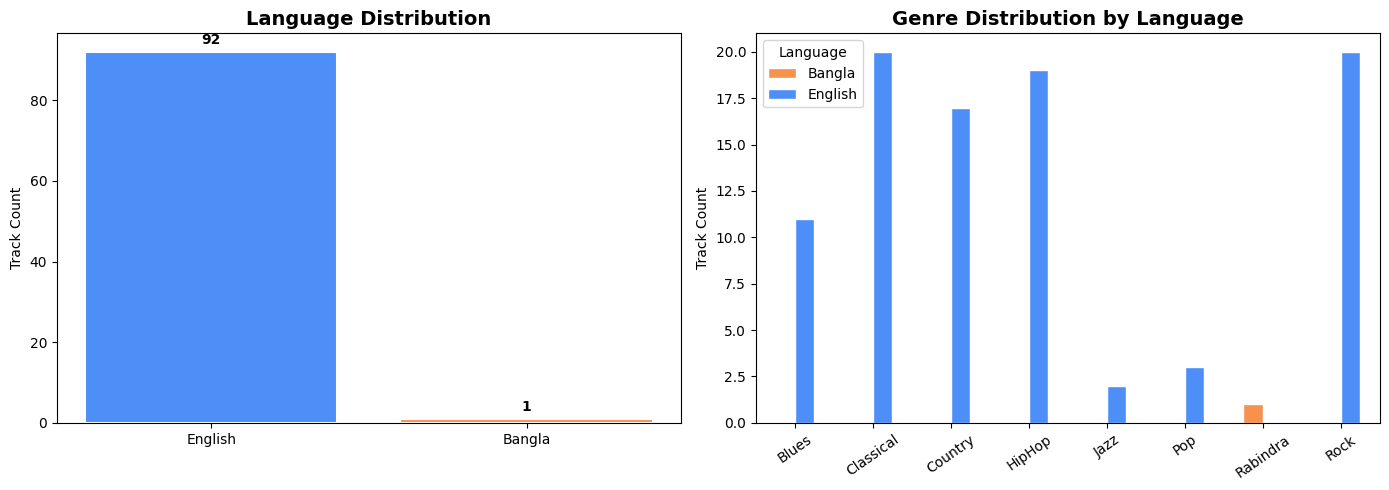

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Language distribution
lang_counts = df['language'].value_counts()
colors_lang = ['#4e8ef7', '#f7914e']
axes[0].bar(lang_counts.index, lang_counts.values, color=colors_lang, edgecolor='white', linewidth=1.5)
axes[0].set_title('Language Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Track Count')
for i, v in enumerate(lang_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Genre distribution
genre_counts = df.groupby(['genre', 'language']).size().unstack(fill_value=0)
genre_counts.plot(kind='bar', ax=axes[1], color=['#f7914e', '#4e8ef7'], edgecolor='white')
axes[1].set_title('Genre Distribution by Language', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Track Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title='Language')

plt.tight_layout()
plt.savefig('/content/dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 7: VAE Architecture

In [9]:
class Encoder(nn.Module):
    def __init__(self, in_dim, h_dims, z_dim):
        super().__init__()
        layers, prev = [], in_dim
        for h in h_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.LeakyReLU(0.2),
                nn.Dropout(0.2)
            ]
            prev = h
        self.net = nn.Sequential(*layers)
        self.mu_fc = nn.Linear(prev, z_dim)
        self.lv_fc = nn.Linear(prev, z_dim)

    def forward(self, x):
        h = self.net(x)
        return self.mu_fc(h), self.lv_fc(h)


class Decoder(nn.Module):
    def __init__(self, z_dim, h_dims, out_dim):
        super().__init__()
        layers, prev = [], z_dim
        for h in reversed(h_dims):
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.LeakyReLU(0.2),
                nn.Dropout(0.2)
            ]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class VAE(nn.Module):
    def __init__(self, in_dim, h_dims, z_dim):
        super().__init__()
        self.enc = Encoder(in_dim, h_dims, z_dim)
        self.dec = Decoder(z_dim, h_dims, in_dim)

    def reparameterize(self, mu, lv):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * lv)
        return mu

    def forward(self, x):
        mu, lv = self.enc(x)
        z = self.reparameterize(mu, lv)
        return self.dec(z), mu, lv, z


def vae_loss(recon, x, mu, lv, beta=1.0):
    """β-VAE ELBO: Reconstruction MSE + β × KL divergence"""
    rl = F.mse_loss(recon, x, reduction='sum') / x.size(0)
    kl = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / x.size(0)
    return rl + beta * kl, rl.item(), kl.item()


print('VAE defined: Encoder → μ/σ → Reparameterize → Decoder')

VAE defined: Encoder → μ/σ → Reparameterize → Decoder


## Step 8: Train the VAE

In [10]:
INPUT_DIM = X_scaled.shape[1]
HIDDEN_DIMS = [256, 128]
LATENT_DIM = 16
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-3
BETA = 1.0

X_tensor = torch.FloatTensor(X_scaled)
loader = DataLoader(TensorDataset(X_tensor),
                      batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

vae = VAE(INPUT_DIM, HIDDEN_DIMS, LATENT_DIM).to(DEVICE)
optimizer = optim.AdamW(vae.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in vae.parameters())
print(f'VAE | Params: {total_params:,}')
print(f'{INPUT_DIM} → {HIDDEN_DIMS} → z{LATENT_DIM}')
print(f'β={BETA} | LR={LR} | Batch={BATCH_SIZE} | Epochs={EPOCHS}')
print()

history = {'total': [], 'recon': [], 'kl': []}
best_loss = float('inf')
best_state = None

for epoch in range(1, EPOCHS + 1):
    vae.train()
    et = er = ek = nb = 0
    for (bx,) in loader:
        bx = bx.to(DEVICE)
        optimizer.zero_grad()
        recon, mu, lv, _ = vae(bx)
        loss, rl, kl = vae_loss(recon, bx, mu, lv, BETA)
        loss.backward()
        nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
        optimizer.step()
        et += loss.item(); er += rl; ek += kl; nb += 1

    scheduler.step()
    at, ar, ak = et/nb, er/nb, ek/nb
    history['total'].append(at)
    history['recon'].append(ar)
    history['kl'].append(ak)

    if at < best_loss:
        best_loss  = at
        best_state = {k: v.cpu().clone() for k, v in vae.state_dict().items()}

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | Total={at:.4f}  Recon={ar:.4f}  KL={ak:.4f}')

print(f'\nTraining done! Best loss: {best_loss:.4f}')
vae.load_state_dict(best_state)

VAE | Params: 126,342
102 → [256, 128] → z16
β=1.0 | LR=0.001 | Batch=32 | Epochs=100

Epoch   1/100 | Total=123.0360  Recon=120.1988  KL=2.8372
Epoch  20/100 | Total=81.3840  Recon=73.5791  KL=7.8049
Epoch  40/100 | Total=69.3647  Recon=59.2590  KL=10.1057
Epoch  60/100 | Total=66.0108  Recon=54.9656  KL=11.0452
Epoch  80/100 | Total=63.3583  Recon=52.5044  KL=10.8539
Epoch 100/100 | Total=65.7387  Recon=54.5386  KL=11.2001

Training done! Best loss: 62.6674


<All keys matched successfully>

## Step 9: Training Curves

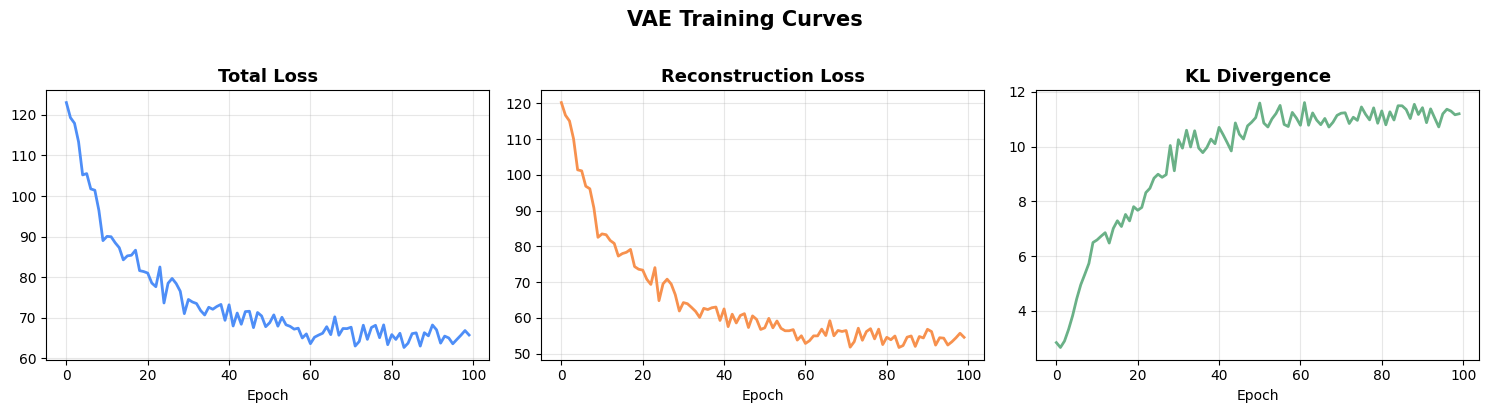

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, color, title in zip(
    axes,
    ['total', 'recon', 'kl'],
    ['#4e8ef7', '#f7914e', '#6ab187'],
    ['Total Loss', 'Reconstruction Loss', 'KL Divergence']
):
    ax.plot(history[key], color=color, linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)

plt.suptitle('VAE Training Curves', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 10: Extract Latent Representations

In [12]:
vae.eval()
with torch.no_grad():
    all_Z = []
    for i in range(0, len(X_tensor), 256):
        batch = X_tensor[i:i+256].to(DEVICE)
        _, mu, _, _ = vae(batch)
        all_Z.append(mu.cpu().numpy())

Z = np.vstack(all_Z)
print(f'Latent space extracted: {Z.shape}  (N samples × {LATENT_DIM} dims)')

Latent space extracted: (93, 16)  (N samples × 16 dims)


## Step 11: Optimal K — Elbow Method

Elbow sweep: 100%|██████████| 14/14 [00:00<00:00, 26.85it/s]


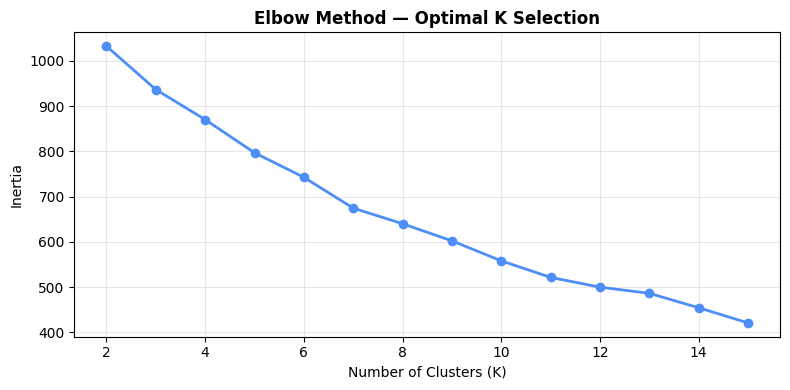

Using K = 8 (number of unique genres)


In [13]:
inertias = []
K_range = range(2, 16)

for k in tqdm(K_range, desc='Elbow sweep'):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(Z)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, 'o-', color='#4e8ef7', linewidth=2, markersize=6)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K Selection', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

# Pick K = number of unique genres in dataset
K = len(le_genre.classes_)
print(f'Using K = {K} (number of unique genres)')

## Step 12: K-Means Clustering on VAE Latent Space

In [14]:
km_vae = KMeans(n_clusters=K, n_init=20, random_state=42)
labels_vae = km_vae.fit_predict(Z)
print(f'VAE + KMeans clustering done (K={K})')
print(f'Cluster sizes: {np.bincount(labels_vae)}')

VAE + KMeans clustering done (K=8)
Cluster sizes: [ 7 12 17  8 14 11 14 10]


## Step 13: Baseline — PCA + K-Means

In [15]:
pca = PCA(n_components=LATENT_DIM, random_state=42)
Z_pca = pca.fit_transform(X_scaled)

km_pca= KMeans(n_clusters=K, n_init=20, random_state=42)
labels_pca = km_pca.fit_predict(Z_pca)

print(f'PCA + KMeans baseline done')
print(f'PCA explained variance ({LATENT_DIM} components): {pca.explained_variance_ratio_.sum():.2%}')

PCA + KMeans baseline done
PCA explained variance (16 components): 76.23%


## Step 14: t-SNE Visualization

Running t-SNE...
t-SNE done.


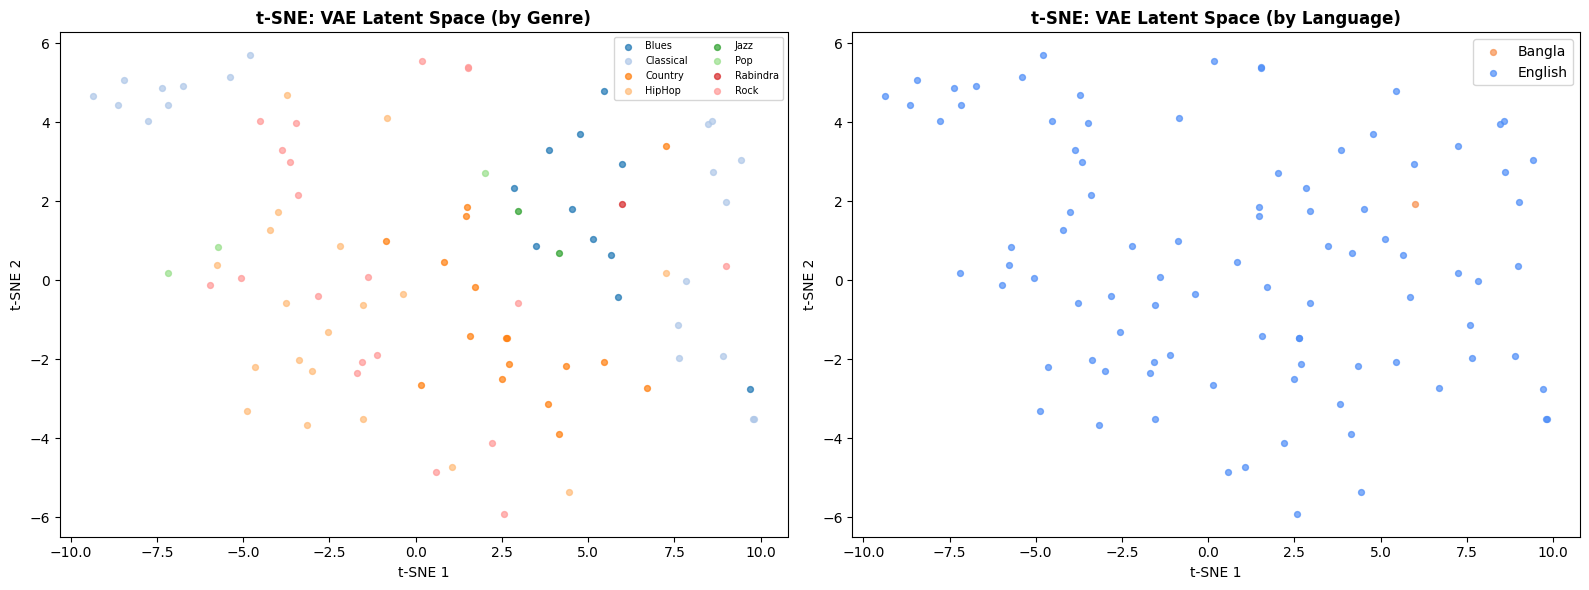

Saved: tsne_visualization.png


In [16]:
print('Running t-SNE...')
tsne = TSNE(n_components=2, perplexity=min(30, len(Z) // 4),
            n_iter=1000, random_state=42)
Z_tsne = tsne.fit_transform(Z)
print('t-SNE done.')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By genre
palette = plt.cm.tab20.colors
for i, genre in enumerate(le_genre.classes_):
    mask = y_genre == i
    axes[0].scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
                    c=[palette[i % len(palette)]], label=genre, alpha=0.7, s=18)
axes[0].set_title('t-SNE: VAE Latent Space (by Genre)', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=7, ncol=2)
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')

# By language
colors_lang = {0: '#f7914e', 1: '#4e8ef7'}  # 0=Bangla, 1=English
lang_names  = le_lang.classes_
for lid in [0, 1]:
    mask = y_lang == lid
    axes[1].scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
                    c=colors_lang[lid], label=lang_names[lid], alpha=0.7, s=18)
axes[1].set_title('t-SNE: VAE Latent Space (by Language)', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.savefig('/content/tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tsne_visualization.png')

## Step 15: UMAP Visualization

Running UMAP...
UMAP done.


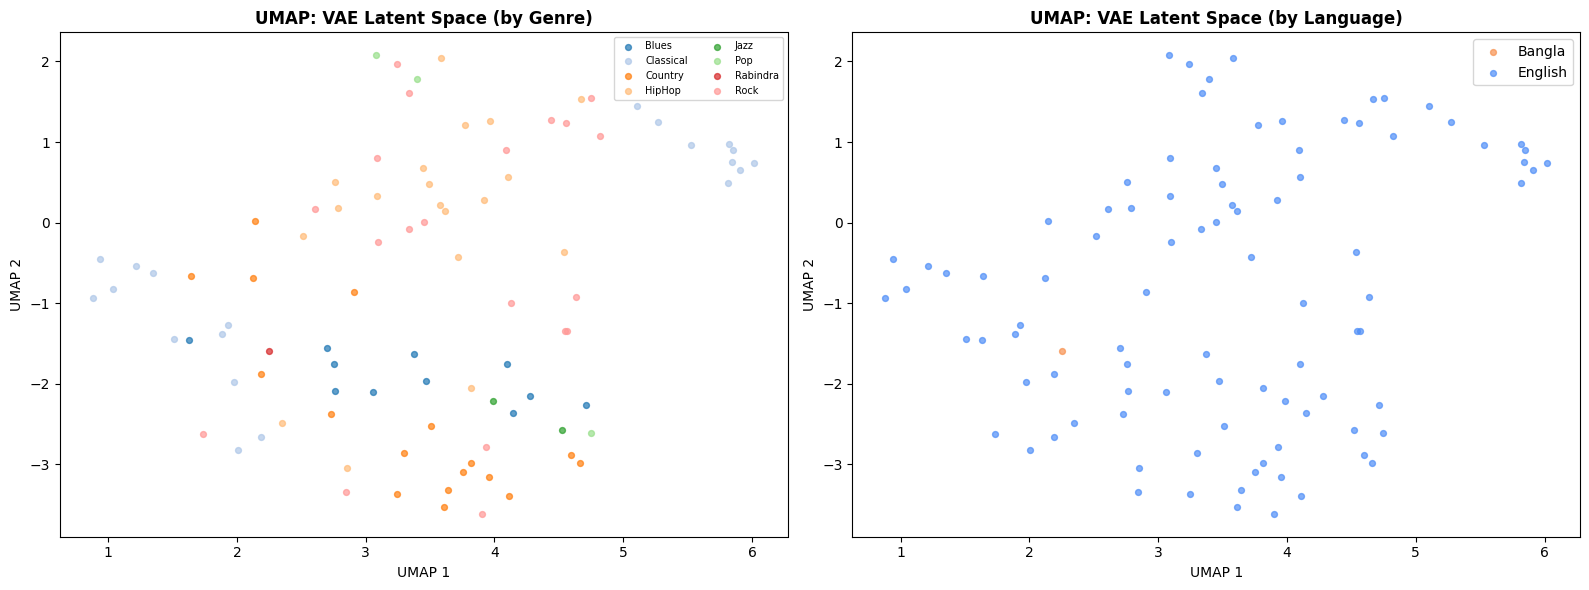

Saved: umap_visualization.png


In [17]:
print('Running UMAP...')
reducer = umap.UMAP(n_components=2, n_neighbors=min(15, len(Z) - 1),
                    min_dist=0.1, random_state=42)
Z_umap  = reducer.fit_transform(Z)
print('UMAP done.')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By genre
for i, genre in enumerate(le_genre.classes_):
    mask = y_genre == i
    axes[0].scatter(Z_umap[mask, 0], Z_umap[mask, 1],
                    c=[palette[i % len(palette)]], label=genre, alpha=0.7, s=18)
axes[0].set_title('UMAP: VAE Latent Space (by Genre)', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=7, ncol=2)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')

# By language
for lid in [0, 1]:
    mask = y_lang == lid
    axes[1].scatter(Z_umap[mask, 0], Z_umap[mask, 1],
                    c=colors_lang[lid], label=lang_names[lid], alpha=0.7, s=18)
axes[1].set_title('UMAP: VAE Latent Space (by Language)', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

plt.tight_layout()
plt.savefig('/content/umap_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: umap_visualization.png')

## Step 16: Evaluation Metrics — VAE vs PCA Baseline


          EVALUATION RESULTS
      Method  Silhouette Score  Calinski-Harabasz
VAE + KMeans            0.1600               11.3
PCA + KMeans            0.1261               10.1
Silhouette winner : VAE
CH Index winner: VAE


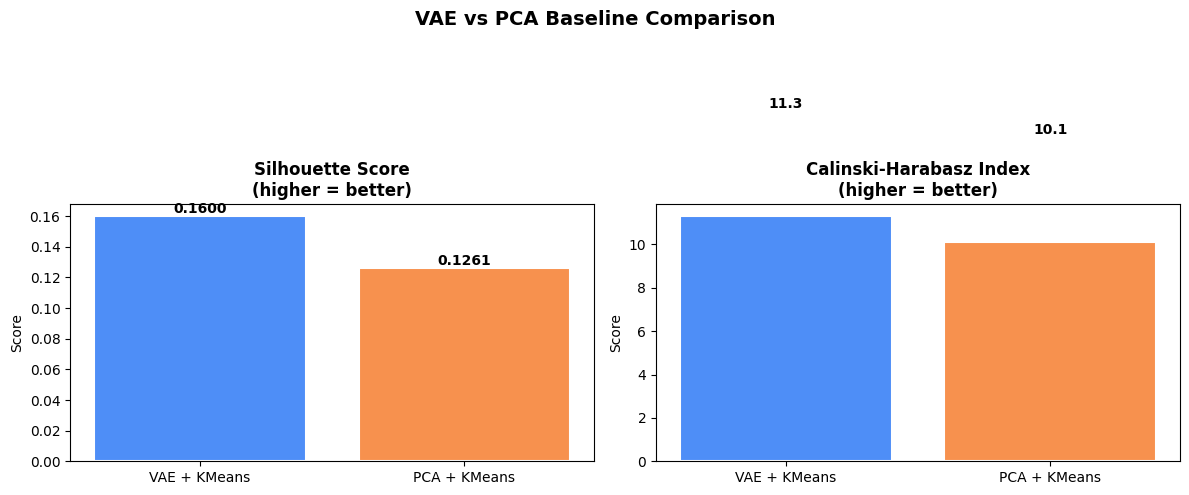

In [18]:
sil_vae = silhouette_score(Z,     labels_vae)
sil_pca = silhouette_score(Z_pca, labels_pca)
ch_vae  = calinski_harabasz_score(Z,     labels_vae)
ch_pca  = calinski_harabasz_score(Z_pca, labels_pca)

results = pd.DataFrame({
    'Method':['VAE + KMeans', 'PCA + KMeans'],
    'Silhouette Score':[round(sil_vae, 4), round(sil_pca, 4)],
    'Calinski-Harabasz':[round(ch_vae, 2),  round(ch_pca, 2)],
})

print('\n' + '='*50)
print('          EVALUATION RESULTS')
print('='*50)
print(results.to_string(index=False))
print('='*50)
print(f'Silhouette winner : {"VAE" if sil_vae > sil_pca else "PCA"}')
print(f'CH Index winner: {"VAE" if ch_vae > ch_pca else "PCA"}')


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
methods = ['VAE + KMeans', 'PCA + KMeans']
bar_colors = ['#4e8ef7', '#f7914e']

axes[0].bar(methods, [sil_vae, sil_pca], color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Silhouette Score\n(higher = better)', fontweight='bold')
axes[0].set_ylabel('Score')
for i, v in enumerate([sil_vae, sil_pca]):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(methods, [ch_vae, ch_pca], color=bar_colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Calinski-Harabasz Index\n(higher = better)', fontweight='bold')
axes[1].set_ylabel('Score')
for i, v in enumerate([ch_vae, ch_pca]):
    axes[1].text(i, v + 5, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('VAE vs PCA Baseline Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 17: Cluster Composition — Language Mix per Cluster

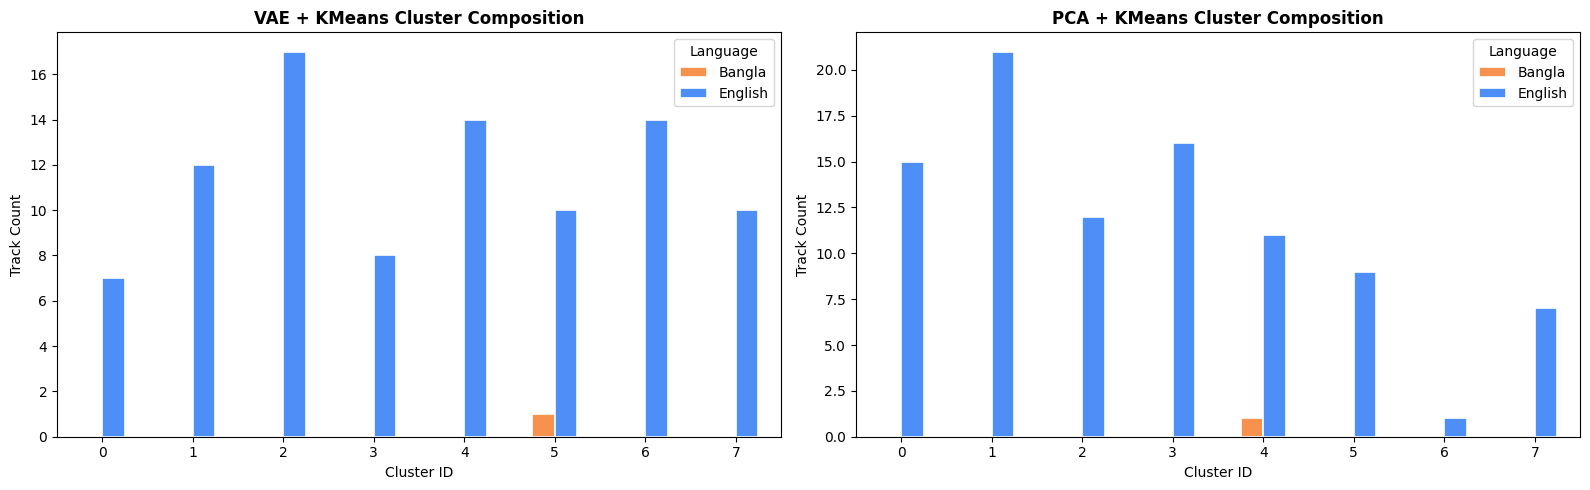

In [19]:
df['cluster_vae'] = labels_vae
df['cluster_pca'] = labels_pca

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ['cluster_vae', 'cluster_pca'],
    ['VAE + KMeans Cluster Composition', 'PCA + KMeans Cluster Composition']
):
    comp = df.groupby([col, 'language']).size().unstack(fill_value=0)
    comp.plot(kind='bar', ax=ax, color=['#f7914e', '#4e8ef7'],
              edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cluster ID')
    ax.set_ylabel('Track Count')
    ax.legend(title='Language')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/content/cluster_composition.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 19: Save & Download All Results

In [20]:
import shutil

# Save model
torch.save({
    'model_state': best_state,
    'config': {
        'input_dim':INPUT_DIM,
        'hidden_dims': HIDDEN_DIMS,
        'latent_dim': LATENT_DIM,
        'beta':BETA,
    },
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
}, '/content/vae_music_model.pt')

# Save latent codes + labels
np.save('/content/latent_Z.npy', Z)
df[['file', 'genre', 'language', 'cluster_vae', 'cluster_pca']].to_csv(
    '/content/cluster_assignments.csv', index=False)
results.to_csv('/content/metrics_table.csv', index=False)

# Zip everything
OUT_DIR = '/content/vae_hybrid_outputs'
os.makedirs(OUT_DIR, exist_ok=True)
for f in [
    '/content/vae_music_model.pt',
    '/content/latent_Z.npy',
    '/content/cluster_assignments.csv',
    '/content/metrics_table.csv',
    '/content/dataset_distribution.png',
    '/content/training_curves.png',
    '/content/elbow_method.png',
    '/content/tsne_visualization.png',
    '/content/umap_visualization.png',
    '/content/metrics_comparison.png',
    '/content/cluster_composition.png',
]:
    if os.path.exists(f):
        shutil.copy(f, OUT_DIR)

shutil.make_archive('/content/vae_hybrid_results', 'zip', OUT_DIR)

from google.colab import files
files.download('/content/vae_hybrid_results.zip')
print('Download started!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!
